In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def gaussian_network(N, J):
    return np.random.randn(N, N) * (J / np.sqrt(N))

def erdos_renyi_network(N, p, J):
    mask = (np.random.rand(N, N) < p)
    W = np.random.randn(N, N) * mask
    return W * (J / np.sqrt(N * p))

def derivatives(W, r):
    return -r + np.tanh(W @ r)

def simulate(W, r0, dt, T):
    n_steps = int(T / dt)
    times = np.arange(n_steps) * dt
    traj = np.zeros((n_steps, len(r0)))
    r = r0.copy()

    for t in range(n_steps):
        traj[t] = r
        r = r + dt * derivatives(W, r)

    return times, traj

def activation_histogram_over_time(traj, times, n_bins=80, act_min=-1, act_max=1):
    bin_edges = np.linspace(act_min, act_max, n_bins + 1)
    hist = np.zeros((n_bins, len(times)))

    for i in range(len(times)):
        counts, _ = np.histogram(traj[i], bins=bin_edges)
        hist[:, i] = counts

    return hist, bin_edges

def plot_sampled_neurons(times, traj, n_sample=25, title="Neuron activity"):
    sampled = np.random.choice(traj.shape[1], size=n_sample, replace=False)
    plt.figure(figsize=(10, 6))
    for i in sampled:
        plt.plot(times, traj[:, i], linewidth=1)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("activation")
    plt.tight_layout()
    plt.show()

def plot_histogram_heatmap(hist, times, act_min=-1, act_max=1, title="Activation histogram over time"):
    plt.figure(figsize=(10, 6))
    im = plt.imshow(
        hist,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], act_min, act_max]
    )
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("activation")
    cbar = plt.colorbar(im)
    cbar.set_label("count")
    plt.tight_layout()
    plt.show()

In [4]:
N = 200
J = 1.4
dt = 0.01
T = 100
p = 0.1

np.random.seed(0)
r0 = np.random.uniform(-0.1, 0.1, N)

## Gaussian network
Simulation and plots for the fully connected Gaussian case.

In [6]:
W_gauss = gaussian_network(N, J)
times_g, traj_g = simulate(W_gauss, r0, dt, T)
hist_g, _ = activation_histogram_over_time(traj_g, times_g)

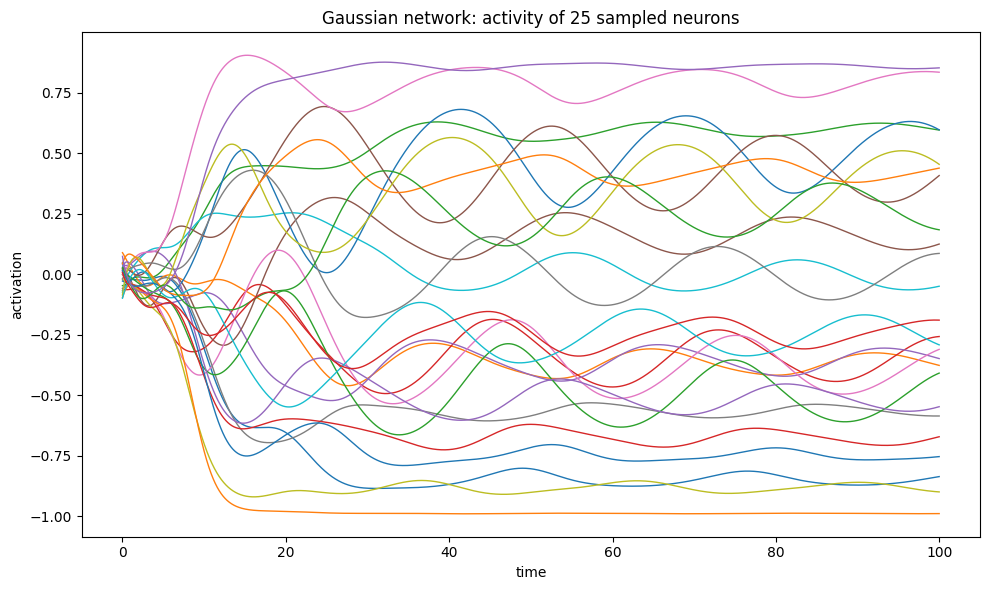

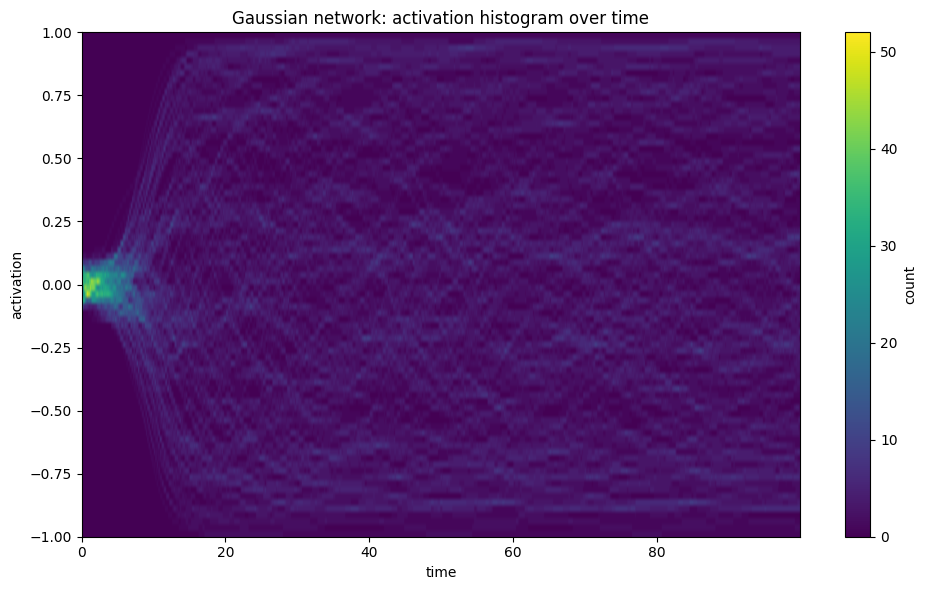

In [7]:
plot_sampled_neurons(
    times_g,
    traj_g,
    title="Gaussian network: activity of 25 sampled neurons"
)

plot_histogram_heatmap(
    hist_g,
    times_g,
    title="Gaussian network: activation histogram over time"
)

## Erdos-Renyi network
Simulation and plots for the sparse random network case.

In [8]:
W_er = erdos_renyi_network(N, p, J)
times_er, traj_er = simulate(W_er, r0, dt, T)
hist_er, _ = activation_histogram_over_time(traj_er, times_er)

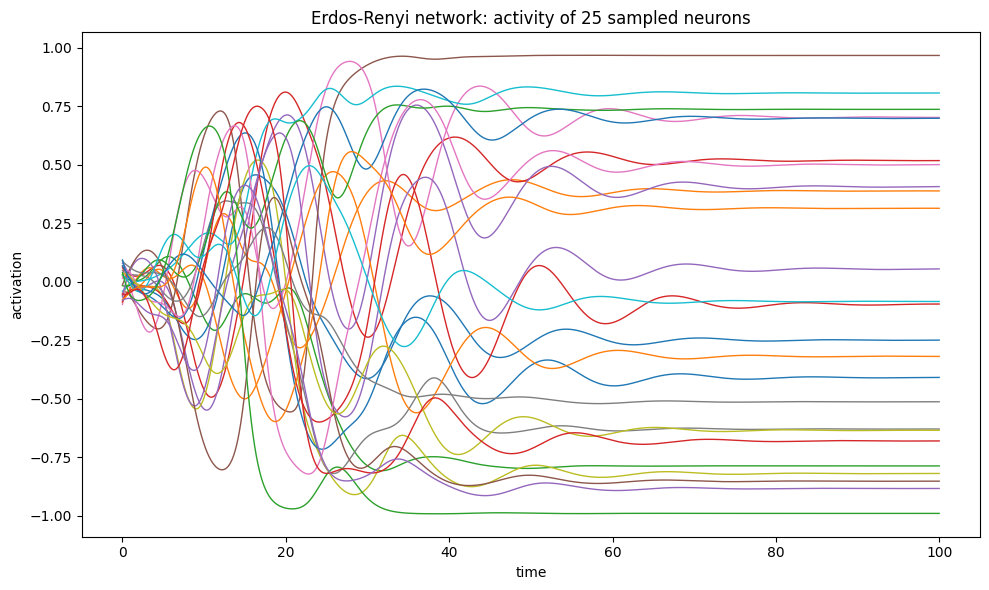

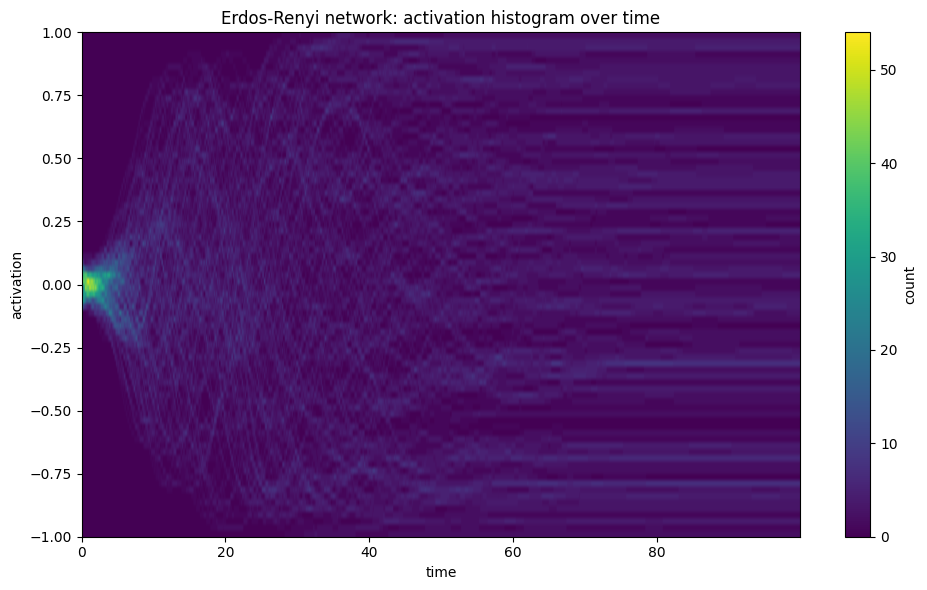

In [9]:
plot_sampled_neurons(
    times_er,
    traj_er,
    title="Erdos-Renyi network: activity of 25 sampled neurons"
)

plot_histogram_heatmap(
    hist_er,
    times_er,
    title="Erdos-Renyi network: activation histogram over time"
)

## Short comment

The heatmap shows how the distribution of neuron activations evolves over time. At the beginning, most neurons are close to zero because of the small random initial condition. Then the activity spreads due to recurrent interactions and fills a broad interval between -1 and 1. This suggests a complex recurrent regime, while the tanh nonlinearity keeps the activations bounded.